# 005 -- Backtest and Validation

**Author:** Wayne Kirk Schmidt  
**Email:** wayne.kirk.schmidt@gmail.com

## Purpose

`005_backtest.ipynb` is the fifth and final analytical stage of the cryptocurrency statistical arbitrage research pipeline.

This notebook evaluates the leader-follower signal identified in Stage 4 by simulating trades under realistic execution assumptions, measuring performance, and testing statistical robustness.

The goal of this stage is **validation**: to determine whether the edge observed in Stage 4 survives realistic transaction costs, execution delays, and out-of-sample time periods.

## Inputs

From `output/004_strategy/` and `output/002_enrich/`:

| File | Description |
|------|-------------|
| `event_response_expanded.pkl` | Event-level leader-follower response dataset with per-lag returns |
| `returns_full.pkl` | Daily return series for all assets |
| `price_wide.pkl` | Wide-format price series (for diagnostics) |

## Outputs

Written to `output/005_backtest/`:

| File | Description |
|------|-------------|
| `trade_df.pkl` | Full trade-level dataset |
| `daily_returns.pkl` | Aggregated daily return series |
| `equity_curve.pkl` | Cumulative equity curve |
| `performance_summary.pkl` | Summary performance metrics |
| `grid_results.pkl` | Stress-grid results across all delay/cost scenarios |
| `walkforward_results.pkl` | Walk-forward fold performance |

## Tasks

1. **Signal construction** -- rebuild the filtered and strong event sets from the expanded event response data
2. **Trade construction** -- map signals to directional trades using t+n forward returns
3. **Trade simulation** -- run across a grid of execution delays (0-3 days) and transaction costs (20-40 bps)
4. **Performance evaluation** -- Sharpe ratio, drawdown, hit rate
5. **Statistical significance** -- t-test on daily returns; Sharpe CI via Lo (2002)
6. **Walk-forward robustness** -- performance across 3 non-overlapping time folds

## Pipeline Position

```
001_download  -> data acquisition
002_enrich    -> feature engineering
003_analysis  -> shock detection
004_strategy  -> signal construction
005_backtest  <- you are here
```

## Design Principles

- **Deterministic** -- operates exclusively on persisted artifacts; no recomputation of prior stages
- **No forward-looking assumptions** -- all results derived from information available at time of event
- **Full artifact persistence** -- every output is saved and registered in the manifest


### 1. Imports and Environment Setup

Standard library imports for data manipulation, statistics, file I/O, and visualization.


In [1]:
import pandas as pd
import numpy as np
import pickle
from datetime import datetime, UTC
import math
from pathlib import Path
import matplotlib.pyplot as plt
from scipy import stats


### 2. Environment Configuration

Defines the asset universe, pipeline parameters, and output directories for this stage.


In [2]:
startdate = "2023-01-01"
trading_days = 252
frequency = "1d"

universe = [
    "BTCUSDT",   # Bitcoin
    "ETHUSDT",   # Ethereum
    "BNBUSDT",   # Binance Coin
    "SOLUSDT",   # Solana
    "XRPUSDT",   # Ripple
    "ADAUSDT",   # Cardano
    "DOGEUSDT",  # Dogecoin
    "AVAXUSDT",  # Avalanche
    "LTCUSDT"    # Litecoin
]

execution_delay = [0, 1, 2, 3]
execution_cost_bps = [20, 30, 40]

stage_label = "005_backtest"

OUTPUT_ROOT = Path("../output")
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

MANIFEST_FILE = OUTPUT_ROOT / "manifest.pkl"

DOWNLOAD_DIR = OUTPUT_ROOT / "001_download"
DOWNLOAD_DIR.mkdir(parents=True, exist_ok=True)

ENRICH_DIR = OUTPUT_ROOT / "002_enrich"
ENRICH_DIR.mkdir(parents=True, exist_ok=True)

ANALYSIS_DIR = OUTPUT_ROOT / "003_analysis"
ANALYSIS_DIR.mkdir(parents=True, exist_ok=True)

STRATEGY_DIR = OUTPUT_ROOT / "004_strategy"
STRATEGY_DIR.mkdir(parents=True, exist_ok=True)

BACKTEST_DIR = OUTPUT_ROOT / "005_backtest"
BACKTEST_DIR.mkdir(parents=True, exist_ok=True)

inspection_window = 20

sigma_threshold = 3

observation_window_length = 10
observation_window = range(1, observation_window_length + 1)

holding_period = 1


### 3. Load or Initialize the Manifest

Loads the shared pipeline manifest and initializes this stage's entry if not already present.


In [3]:
if MANIFEST_FILE.exists():
    manifest = pd.read_pickle(MANIFEST_FILE)
else:
    manifest = {}

manifest.setdefault(stage_label, {})

{}

### 4. Load Required Artifacts from Prior Stages

Loads the event response dataset from Stage 4 and the enriched return/price data from Stage 2. Raises a descriptive error if any required file is missing.


In [4]:
required_files = {
    "event_response_expanded": (
        STRATEGY_DIR / "event_response_expanded.pkl"
    ),
    "returns_full": (
        ENRICH_DIR / "returns_full.pkl"
    ),
    "price_wide": (
        ENRICH_DIR / "price_wide.pkl"
    ),
}

data = {}

for name, path in required_files.items():
    if not path.exists():
        raise FileNotFoundError(f"Missing required file: {path}")
    data[name] = pd.read_pickle(path)

event_response_expanded = data["event_response_expanded"]
returns_full = data["returns_full"]
price_wide = data["price_wide"]

print("Loaded artifacts:\n")

print("event_response_expanded:", event_response_expanded.shape)
print(event_response_expanded.columns.tolist(), "\n")

print("returns_full:", returns_full.shape)
print("price_wide:", price_wide.shape)

Loaded artifacts:

event_response_expanded: (2320, 14)
['event_date', 'reference_coin', 'target_coin', 'sigma', 'lag_1', 'lag_2', 'lag_3', 'lag_4', 'lag_5', 'lag_6', 'lag_7', 'lag_8', 'lag_9', 'lag_10'] 

returns_full: (1047, 9)
price_wide: (1242, 9)


### 5. Standardize Column Names

Renames columns to the convention used throughout this notebook (`r_coin`, `f_coin`, `date`) for consistency with the trade construction logic below.


In [5]:
event_full_df = event_response_expanded.copy()
event_full_df = event_full_df.rename(columns={
    "reference_coin": "r_coin",
    "target_coin": "f_coin",
    "event_date": "date"
})

print("event_full_df:", event_full_df.shape)
print(event_full_df.columns.tolist())

print("\nSample:")
print(event_full_df.head())

event_full_df: (2320, 14)
['date', 'r_coin', 'f_coin', 'sigma', 'lag_1', 'lag_2', 'lag_3', 'lag_4', 'lag_5', 'lag_6', 'lag_7', 'lag_8', 'lag_9', 'lag_10']

Sample:
                       date   r_coin    f_coin  sigma     lag_1     lag_2  \
0 2023-08-03 00:00:00+00:00  LTCUSDT   ADAUSDT     -3  0.004098 -0.001020   
1 2023-08-03 00:00:00+00:00  LTCUSDT  AVAXUSDT     -3 -0.003213  0.002417   
2 2023-08-03 00:00:00+00:00  LTCUSDT   BNBUSDT     -3  0.001663  0.007884   
3 2023-08-03 00:00:00+00:00  LTCUSDT   BTCUSDT     -3 -0.002569 -0.001855   
4 2023-08-03 00:00:00+00:00  LTCUSDT  DOGEUSDT     -3 -0.001764  0.028688   

      lag_3     lag_4     lag_5     lag_6     lag_7     lag_8     lag_9  \
0 -0.006129 -0.003768  0.023384  0.011089 -0.014955 -0.009447 -0.006131   
1  0.011254 -0.011924  0.021722 -0.004724 -0.011867 -0.004804 -0.004023   
2  0.000412 -0.004938  0.014475 -0.006115 -0.010254 -0.005387  0.000417   
3  0.000888  0.003721  0.019690 -0.006716 -0.004086 -0.000918 -0.000073  

### 6. Build and Filter Event Sets by Signal Direction

Constructs three event sets based on directional consistency between the reference coin's shock and the follower asset's forward returns:

- **Full** -- all events where sigma ≥ 3 or ≤ −3
- **Filtered** -- events where lag_1 direction matches the reference shock direction
- **Strong** -- events where lag_1, lag_2, and lag_3 all align with the reference shock direction

The filtered set is used as the primary signal throughout the backtest.


In [6]:
df = event_response_expanded.copy()

df["r_sign"] = np.sign(df["sigma"])

df["f_sign0"] = np.sign(df["lag_1"])
df["f_sign1"] = np.sign(df["lag_2"])
df["f_sign2"] = np.sign(df["lag_3"])

df = df.rename(columns={
    "reference_coin": "r_coin",
    "target_coin": "f_coin",
    "event_date": "date"
})

event_full_df = df

event_filtered_df = event_full_df[
    event_full_df["r_sign"] == event_full_df["f_sign0"]
]

event_strong_df = event_full_df[
    (event_full_df["r_sign"] == event_full_df["f_sign0"]) &
    (event_full_df["r_sign"] == event_full_df["f_sign1"]) &
    (event_full_df["r_sign"] == event_full_df["f_sign2"])
]

print("columns:")
print(event_full_df.columns.tolist())

print("\ncounts:")
print("full:", len(event_full_df))
print("filtered:", len(event_filtered_df))
print("strong:", len(event_strong_df))

print("\nsample:")
print(event_full_df[[
    "date", "r_coin", "f_coin",
    "sigma", "r_sign",
    "f_sign0", "f_sign1", "f_sign2"
]].head())

columns:
['date', 'r_coin', 'f_coin', 'sigma', 'lag_1', 'lag_2', 'lag_3', 'lag_4', 'lag_5', 'lag_6', 'lag_7', 'lag_8', 'lag_9', 'lag_10', 'r_sign', 'f_sign0', 'f_sign1', 'f_sign2']

counts:
full: 2320
filtered: 1077
strong: 189

sample:
                       date   r_coin    f_coin  sigma  r_sign  f_sign0  \
0 2023-08-03 00:00:00+00:00  LTCUSDT   ADAUSDT     -3      -1      1.0   
1 2023-08-03 00:00:00+00:00  LTCUSDT  AVAXUSDT     -3      -1     -1.0   
2 2023-08-03 00:00:00+00:00  LTCUSDT   BNBUSDT     -3      -1      1.0   
3 2023-08-03 00:00:00+00:00  LTCUSDT   BTCUSDT     -3      -1     -1.0   
4 2023-08-03 00:00:00+00:00  LTCUSDT  DOGEUSDT     -3      -1     -1.0   

   f_sign1  f_sign2  
0     -1.0     -1.0  
1      1.0      1.0  
2      1.0      1.0  
3     -1.0      1.0  
4      1.0     -1.0  


### 7. Select the Active Event Set

Sets `ACTIVE_SET` to select which event population is used for all downstream trade construction and simulation. Default is `"filtered"` -- the directionally consistent subset.


In [7]:
ACTIVE_SET = "filtered"  # options: "full", "filtered", "strong"

if ACTIVE_SET == "full":
    events = event_full_df.copy()
elif ACTIVE_SET == "filtered":
    events = event_filtered_df.copy()
elif ACTIVE_SET == "strong":
    events = event_strong_df.copy()
else:
    raise ValueError("Invalid ACTIVE_SET")

print("active set:", ACTIVE_SET)
print("rows:", len(events))
print("columns:", events.columns.tolist())
print("\nsample:")
print(events.head())

active set: filtered
rows: 1077
columns: ['date', 'r_coin', 'f_coin', 'sigma', 'lag_1', 'lag_2', 'lag_3', 'lag_4', 'lag_5', 'lag_6', 'lag_7', 'lag_8', 'lag_9', 'lag_10', 'r_sign', 'f_sign0', 'f_sign1', 'f_sign2']

sample:
                       date   r_coin    f_coin  sigma     lag_1     lag_2  \
1 2023-08-03 00:00:00+00:00  LTCUSDT  AVAXUSDT     -3 -0.003213  0.002417   
3 2023-08-03 00:00:00+00:00  LTCUSDT   BTCUSDT     -3 -0.002569 -0.001855   
4 2023-08-03 00:00:00+00:00  LTCUSDT  DOGEUSDT     -3 -0.001764  0.028688   
5 2023-08-03 00:00:00+00:00  LTCUSDT   ETHUSDT     -3 -0.002887  0.003103   
7 2023-08-03 00:00:00+00:00  LTCUSDT   XRPUSDT     -3 -0.045755 -0.010847   

      lag_3     lag_4     lag_5     lag_6     lag_7     lag_8     lag_9  \
1  0.011254 -0.011924  0.021722 -0.004724 -0.011867 -0.004804 -0.004023   
3  0.000888  0.003721  0.019690 -0.006716 -0.004086 -0.000918 -0.000073   
4 -0.017182 -0.011565  0.020952  0.004797  0.005570 -0.001846  0.013742   
5 -0.003518 -0.

### 8. Trade Mapping

Converts the active event set into a structured trade representation. Each trade captures:
- Entry return: lag_1 (t+1 forward return)
- Exit return: lag_2 (t+2 forward return)
- Direction: sign of the reference coin's shock
- PnL: direction × (entry return + exit return)


In [8]:
trades = events.copy()

trades["entry_date"] = trades["date"]
trades["exit_date"] = trades["date"]

trades["ret_entry"] = trades["lag_1"]   # t+1
trades["ret_exit"]  = trades["lag_2"]   # t+2

trades["direction"] = trades["r_sign"]

trades["pnl"] = trades["direction"] * (trades["ret_entry"] + trades["ret_exit"])

trade_df = trades[[
    "date",
    "r_coin",
    "f_coin",
    "direction",
    "ret_entry",
    "ret_exit",
    "pnl"
]].copy()

print("trade_df shape:", trade_df.shape)
print("\nsample:")
print(trade_df.head())

trade_df shape: (1077, 7)

sample:
                       date   r_coin    f_coin  direction  ret_entry  \
1 2023-08-03 00:00:00+00:00  LTCUSDT  AVAXUSDT         -1  -0.003213   
3 2023-08-03 00:00:00+00:00  LTCUSDT   BTCUSDT         -1  -0.002569   
4 2023-08-03 00:00:00+00:00  LTCUSDT  DOGEUSDT         -1  -0.001764   
5 2023-08-03 00:00:00+00:00  LTCUSDT   ETHUSDT         -1  -0.002887   
7 2023-08-03 00:00:00+00:00  LTCUSDT   XRPUSDT         -1  -0.045755   

   ret_exit       pnl  
1  0.002417  0.000795  
3 -0.001855  0.004424  
4  0.028688 -0.026924  
5  0.003103 -0.000216  
7 -0.010847  0.056602  


### 9. Daily Aggregation and Gross Performance

Aggregates trade PnL by date (one trade per day, unbiased baseline) to produce a daily return series and cumulative equity curve. Computes gross performance metrics before transaction costs are applied.


In [9]:
# Daily aggregation -- equal-weighted mean of all trade PnLs per day
# NOTE: this is a GROSS, PRE-COST, UNADJUSTED metric.
# It reflects raw signal strength only.
# For net performance and proper Sharpe, see the stress grid below.
daily_returns = (
    trade_df
    .groupby("date")["pnl"]
    .mean()
    .sort_index()
)

equity_curve = (1 + daily_returns).cumprod()

print("daily_returns shape:", daily_returns.shape)
print("NOTE: gross pre-cost unadjusted -- see stress grid for net results")
print()
print("Daily return distribution:")
print(daily_returns.describe().round(4))


daily_returns shape: (86,)
NOTE: gross pre-cost unadjusted -- see stress grid for net results

Daily return distribution:
count    86.0000
mean      0.0324
std       0.0486
min      -0.0850
25%       0.0028
50%       0.0245
75%       0.0647
max       0.2110
Name: pnl, dtype: float64


### 10. Net Performance Metrics

Computes the final performance summary over the full trade set including total return, annualized volatility, and Sharpe ratio. This serves as the baseline for the stress-grid evaluation below.


In [10]:
# GROSS UNADJUSTED PERFORMANCE SUMMARY
# This cell computes trade-level metrics WITHOUT:
#   - transaction costs
#   - execution delay
#   - daily aggregation
# These numbers are intentionally inflated and are shown only to
# illustrate raw signal strength. Do NOT cite these as strategy performance.
# See the stress grid (Section 11) for all net performance metrics.

trade_returns = trade_df["pnl"].dropna()

total_return_gross = trade_returns.sum()
sharpe_gross = (
    trade_returns.mean() / trade_returns.std()
) * np.sqrt(trading_days)

print("=== GROSS SIGNAL STRENGTH (pre-cost, trade-level) ===")
print(f"  num_trades:    {len(trade_returns)}")
print(f"  mean per trade:{trade_returns.mean():>+.4f}")
print(f"  gross Sharpe:  {sharpe_gross:.2f}  (inflated -- not meaningful)")
print()
print("  --> See Section 11 (stress grid) for actual net performance.")

performance_summary = pd.Series({
    "total_return":  total_return_gross,
    "volatility":    trade_returns.std() * np.sqrt(trading_days),
    "sharpe":        sharpe_gross,
    "num_trades":    float(len(trade_returns)),
})

=== GROSS SIGNAL STRENGTH (pre-cost, trade-level) ===
  num_trades:    1077
  mean per trade:+0.0326
  gross Sharpe:  8.95  (inflated -- not meaningful)

  --> See Section 11 (stress grid) for actual net performance.


In [11]:
# Helper: reconstruct daily net PnL for any delay/cost scenario
# Used by sections 11, 16, and 17.
def scenario_daily(df, delay, cost_bps):
    """Return daily net PnL series for given execution delay and cost."""
    cost = cost_bps / 10000.0
    sc   = df.copy()
    entry_col = f"lag_{1 + delay}"
    exit_col  = f"lag_{2 + delay}"
    if entry_col not in sc.columns or exit_col not in sc.columns:
        return pd.Series(dtype=float)
    sc["direction"] = sc["r_sign"]
    leg1 = sc[["date", "f_coin", "direction", entry_col]].copy()
    leg1["date"] += pd.Timedelta(days=1)
    leg1["net_pnl"] = leg1["direction"] * leg1[entry_col] - cost / 2
    leg2 = sc[["date", "f_coin", "direction", exit_col]].copy()
    leg2["date"] += pd.Timedelta(days=2)
    leg2["net_pnl"] = leg2["direction"] * leg2[exit_col] - cost / 2
    expanded = pd.concat([leg1, leg2], ignore_index=True)
    expanded = (
        expanded
        .sort_values(["date", "f_coin"])
        .groupby("date")
        .head(1)
    )
    return expanded.set_index("date")["net_pnl"].sort_index()


### 11. Run the Execution Stress Grid

Simulates the strategy across all combinations of:
- **Execution delay:** 0, 1, 2, 3 days after the shock event
- **Transaction cost:** 20, 30, 40 basis points (round-trip)

For each scenario, computes total return, annualized volatility, Sharpe ratio, and maximum drawdown. Results are collected for comparison in the next section.


In [12]:
results = []

for delay in execution_delay:
    for cost_bps in execution_cost_bps:

        cost = cost_bps / 10000.0

        scenario_df = events.copy()

        entry_col = f"lag_{1 + delay}"
        exit_col  = f"lag_{2 + delay}"

        if entry_col not in scenario_df.columns or exit_col not in scenario_df.columns:
            continue

        scenario_df["ret_entry"] = scenario_df[entry_col]
        scenario_df["ret_exit"]  = scenario_df[exit_col]

        scenario_df["direction"] = scenario_df["r_sign"]

        # --- PnL construction ---
        leg1 = scenario_df[["date", "f_coin", "direction", "ret_entry"]].copy()
        leg1["date"] = leg1["date"] + pd.Timedelta(days=1)
        leg1["net_pnl"] = leg1["direction"] * leg1["ret_entry"] - cost / 2

        leg2 = scenario_df[["date", "f_coin", "direction", "ret_exit"]].copy()
        leg2["date"] = leg2["date"] + pd.Timedelta(days=2)
        leg2["net_pnl"] = leg2["direction"] * leg2["ret_exit"] - cost / 2

        expanded = pd.concat([leg1, leg2], ignore_index=True)

        # --- keep 1 trade per day (unbiased baseline) ---
        expanded = (
            expanded
            .sort_values(["date", "f_coin"])
            .groupby("date")
            .head(1)
        )

        daily_net = expanded.set_index("date")["net_pnl"].sort_index()

        if len(daily_net) < 2:
            continue

        equity = (1 + daily_net).cumprod()

        total_return = equity.iloc[-1] - 1

        volatility = daily_net.std() * np.sqrt(trading_days)

        sharpe = (
            daily_net.mean() / daily_net.std()
        ) * np.sqrt(trading_days)

        drawdown = equity / equity.cummax() - 1
        max_drawdown = drawdown.min()

        results.append({
            "delay": delay,
            "cost_bps": cost_bps,
            "num_days": len(daily_net),
            "total_return": total_return,
            "volatility": volatility,
            "sharpe": sharpe,
            "max_drawdown": max_drawdown,
        })

print("scenarios calculated:", len(results))

results



scenarios calculated: 12


[{'delay': 0,
  'cost_bps': 20,
  'num_days': 159,
  'total_return': np.float64(3.027864131810766),
  'volatility': np.float64(0.7501198261238219),
  'sharpe': np.float64(3.3250155789485416),
  'max_drawdown': np.float64(-0.2208451015202808)},
 {'delay': 0,
  'cost_bps': 30,
  'num_days': 159,
  'total_return': np.float64(2.722235617368532),
  'volatility': np.float64(0.7501198261238219),
  'sharpe': np.float64(3.157042415712616),
  'max_drawdown': np.float64(-0.2290875568660451)},
 {'delay': 0,
  'cost_bps': 40,
  'num_days': 159,
  'total_return': np.float64(2.439662678459568),
  'volatility': np.float64(0.7501198261238219),
  'sharpe': np.float64(2.989069252476692),
  'max_drawdown': np.float64(-0.2372469333657511)},
 {'delay': 1,
  'cost_bps': 20,
  'num_days': 159,
  'total_return': np.float64(-0.302712803039035),
  'volatility': np.float64(0.7736524520698632),
  'sharpe': np.float64(-0.3591083171203813),
  'max_drawdown': np.float64(-0.4794192708058075)},
 {'delay': 1,
  'cost_bp

### 12. Stress Grid Summary Table

Displays the full stress grid as a formatted DataFrame sorted by execution delay and cost. This is the primary deliverable of the backtest -- a complete picture of how performance varies across realistic execution assumptions.


In [13]:
pd.set_option("display.expand_frame_repr", False)
pd.set_option("display.max_columns", None)

stress_grid = (
    pd.DataFrame(results)
    .sort_values(["delay", "cost_bps"])
    .reset_index(drop=True)
)

print("Stress Grid:")
print(stress_grid)

print("\nShape:", stress_grid.shape)

Stress Grid:
    delay  cost_bps  num_days  total_return  volatility    sharpe  max_drawdown
0       0        20       159      3.027864    0.750120  3.325016     -0.220845
1       0        30       159      2.722236    0.750120  3.157042     -0.229088
2       0        40       159      2.439663    0.750120  2.989069     -0.237247
3       1        20       159     -0.302713    0.773652 -0.359108     -0.479419
4       1        30       159     -0.356189    0.773652 -0.521972     -0.509203
5       1        40       159     -0.405588    0.773652 -0.684836     -0.537297
6       2        20       159     -0.005022    0.751040  0.353386     -0.405472
7       2        30       159     -0.081158    0.751040  0.185619     -0.423500
8       2        40       159     -0.151503    0.751040  0.017852     -0.440990
9       3        20       159      0.492010    0.750233  1.211209     -0.279657
10      3        30       159      0.378119    0.750233  1.043262     -0.290434
11      3        40       1

### 13. Sharpe Ratio Summary by Scenario

Prints the Sharpe ratio for each (delay, cost) combination in a compact table for quick review.


In [14]:
print(stress_grid[["delay", "cost_bps", "sharpe"]])

    delay  cost_bps    sharpe
0       0        20  3.325016
1       0        30  3.157042
2       0        40  2.989069
3       1        20 -0.359108
4       1        30 -0.521972
5       1        40 -0.684836
6       2        20  0.353386
7       2        30  0.185619
8       2        40  0.017852
9       3        20  1.211209
10      3        30  1.043262
11      3        40  0.875314


### 14. Visualize Sharpe Ratio Across the Stress Grid

Plots Sharpe ratio as a function of execution delay for each cost level. A strategy with consistently positive Sharpe across the grid -- and graceful degradation as delay and cost increase -- shows robustness to execution friction.


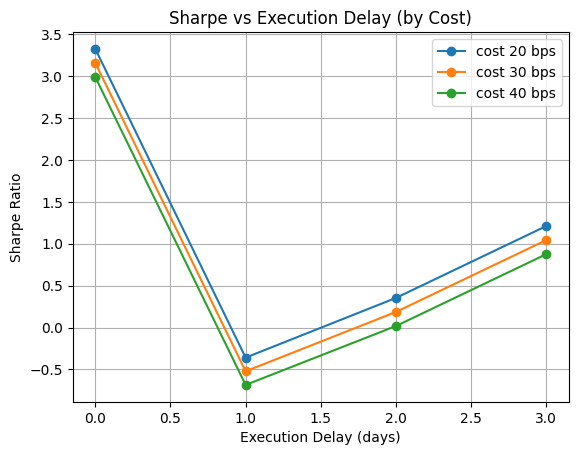



count    159.000000
mean       0.002606
std        0.047260
min       -0.111803
25%       -0.019485
50%        0.002686
75%        0.027145
max        0.216053
Name: net_pnl, dtype: float64


In [15]:
pivot_sharpe = stress_grid.pivot(
    index="delay",
    columns="cost_bps",
    values="sharpe"
)

plt.figure()

for col in pivot_sharpe.columns:
    plt.plot(pivot_sharpe.index, pivot_sharpe[col], marker='o', label=f"cost {col} bps")

plt.xlabel("Execution Delay (days)")
plt.ylabel("Sharpe Ratio")
plt.title("Sharpe vs Execution Delay (by Cost)")

plt.legend()
plt.grid()

plt.show()

print("\n")

print(daily_net.describe())

### 15. Persist Backtest Artifacts

Saves all primary backtest outputs to disk and registers each in the manifest with file existence and non-empty size assertions.


In [16]:
fp = BACKTEST_DIR / "trade_df.pkl"
trade_df.to_pickle(fp)
assert fp.exists(), "trade_df.pkl not written"
assert fp.stat().st_size > 0, "trade_df.pkl is empty"
manifest[stage_label]["trade_df"] = str(fp.relative_to(OUTPUT_ROOT))
print("saved:", fp)

fp = BACKTEST_DIR / "daily_returns.pkl"
daily_returns.to_pickle(fp)
assert fp.exists(), "daily_returns.pkl not written"
assert fp.stat().st_size > 0, "daily_returns.pkl is empty"
manifest[stage_label]["daily_returns"] = str(fp.relative_to(OUTPUT_ROOT))
print("saved:", fp)

fp = BACKTEST_DIR / "equity_curve.pkl"
equity_curve.to_pickle(fp)
assert fp.exists(), "equity_curve.pkl not written"
assert fp.stat().st_size > 0, "equity_curve.pkl is empty"
manifest[stage_label]["equity_curve"] = str(fp.relative_to(OUTPUT_ROOT))
print("saved:", fp)

fp = BACKTEST_DIR / "performance_summary.pkl"
performance_summary.to_pickle(fp)
assert fp.exists(), "performance_summary.pkl not written"
assert fp.stat().st_size > 0, "performance_summary.pkl is empty"
manifest[stage_label]["performance_summary"] = str(fp.relative_to(OUTPUT_ROOT))
print("saved:", fp)

fp = BACKTEST_DIR / "grid_results.pkl"
results_df = pd.DataFrame(results)
results_df.to_pickle(fp)
assert fp.exists(), "grid_results.pkl not written"
assert fp.stat().st_size > 0, "grid_results.pkl is empty"
manifest[stage_label]["grid_results"] = str(fp.relative_to(OUTPUT_ROOT))
print("saved:", fp)


saved: ..\output\005_backtest\trade_df.pkl
saved: ..\output\005_backtest\daily_returns.pkl
saved: ..\output\005_backtest\equity_curve.pkl
saved: ..\output\005_backtest\performance_summary.pkl
saved: ..\output\005_backtest\grid_results.pkl


### 16. Statistical Significance Tests

I test whether the observed mean return is statistically distinguishable from zero, and compute a confidence interval around the annualized Sharpe ratio.

**16a -- One-sample t-test on daily returns (t+0, 20 bps baseline)**

Null hypothesis: mean daily return = 0. A p-value below 0.05 provides evidence that the strategy's returns are not explained by chance.

**16b -- Sharpe ratio confidence interval (Lo, 2002)**

The Lo (2002) formula adjusts the standard error of the Sharpe ratio for non-normality (skewness and excess kurtosis) in the return series -- an important correction for cryptocurrency returns, which exhibit heavy tails. A 95% CI that excludes zero provides evidence the Sharpe is not a sampling artifact.


In [17]:
from scipy import stats

# --- 16a: t-test on daily returns ---
daily_base = scenario_daily(event_filtered_df, delay=0, cost_bps=20)

t_stat, p_value = stats.ttest_1samp(daily_base.dropna(), popmean=0)
n = len(daily_base)
mean_ret = daily_base.mean()
std_ret  = daily_base.std()
se       = std_ret / np.sqrt(n)
ci_lo    = mean_ret - 1.96 * se
ci_hi    = mean_ret + 1.96 * se

print("=== 16a: One-sample t-test -- daily return vs 0 ===")
print(f"  n            : {n}")
print(f"  mean return  : {mean_ret:.4f}  ({mean_ret*100:.2f}% per day)")
print(f"  t-statistic  : {t_stat:.3f}")
print(f"  p-value      : {p_value:.4f}")
print(f"  95% CI       : [{ci_lo:.4f}, {ci_hi:.4f}]")
print()
if p_value < 0.05:
    print("  Interpretation: reject H0 at 5% -- mean return is significantly positive.")
else:
    print("  Interpretation: cannot reject H0 at 5% -- insufficient evidence of positive mean.")

print()

# --- 16b: Sharpe CI via Lo (2002) ---
sr = (mean_ret / std_ret) * np.sqrt(trading_days)
skewness = stats.skew(daily_base)
excess_kurt = stats.kurtosis(daily_base)  # Fisher definition (excess)
sr_se = np.sqrt(
    (1 + 0.5 * sr**2 - skewness * sr + ((excess_kurt + 2) / 4) * sr**2)
    / (n - 1)
)
sr_ci_lo = sr - 1.96 * sr_se
sr_ci_hi = sr + 1.96 * sr_se

print("=== 16b: Sharpe ratio confidence interval (Lo 2002) ===")
print(f"  Annualised Sharpe : {sr:.3f}")
print(f"  Skewness          : {skewness:.3f}")
print(f"  Excess kurtosis   : {excess_kurt:.3f}")
print(f"  SE of Sharpe      : {sr_se:.3f}")
print(f"  95% CI            : [{sr_ci_lo:.3f}, {sr_ci_hi:.3f}]")
print()
if sr_ci_lo > 0:
    print("  Interpretation: the entire 95% CI lies above zero.")
    print("  The annualised Sharpe is significantly positive at t+0.")
else:
    print("  Interpretation: CI crosses zero -- Sharpe is not reliably positive.")


=== 16a: One-sample t-test -- daily return vs 0 ===
  n            : 159
  mean return  : 0.0099  (0.99% per day)
  t-statistic  : 2.641
  p-value      : 0.0091
  95% CI       : [0.0026, 0.0172]

  Interpretation: reject H0 at 5% -- mean return is significantly positive.

=== 16b: Sharpe ratio confidence interval (Lo 2002) ===
  Annualised Sharpe : 3.325
  Skewness          : 0.188
  Excess kurtosis   : 1.221
  SE of Sharpe      : 0.306
  95% CI            : [2.725, 3.925]

  Interpretation: the entire 95% CI lies above zero.
  The annualised Sharpe is significantly positive at t+0.


### 17. Walk-Forward Robustness Test

A single in-sample Sharpe ratio is insufficient evidence of a persistent edge. I split the full date range into three equal, non-overlapping folds and measure performance independently in each.

If the signal is real, I expect positive Sharpe in all three folds. Deterioration over time is consistent with a decaying microstructure edge -- still meaningful, but worth monitoring.

**Scenario evaluated:** t+0 execution, 20 bps transaction cost.


In [18]:
# --- Walk-forward: 3 equal folds ---
daily_base = scenario_daily(event_filtered_df, delay=0, cost_bps=20)
dates_idx  = daily_base.index
n_dates    = len(dates_idx)
fold_size  = n_dates // 3

wf_results = []

print("=== Walk-forward: 3-fold split (t+0, 20 bps) ===")
print(f"  Total trading days : {n_dates}")
print(f"  Days per fold      : ~{fold_size}")
print()

for i in range(3):
    start = dates_idx[i * fold_size]
    end   = dates_idx[min((i + 1) * fold_size - 1, n_dates - 1)]
    fold  = daily_base.loc[start:end].dropna()

    if len(fold) < 2:
        continue

    fold_sr  = (fold.mean() / fold.std()) * np.sqrt(trading_days)
    fold_ret = (1 + fold).prod() - 1
    fold_eq  = (1 + fold).cumprod()
    fold_dd  = (fold_eq / fold_eq.cummax() - 1).min()

    wf_results.append({
        "fold":       i + 1,
        "start":      start.date(),
        "end":        end.date(),
        "n":          len(fold),
        "sharpe":     round(fold_sr,  2),
        "total_return": round(fold_ret, 3),
        "max_drawdown": round(fold_dd,  3),
    })

    print(f"  Fold {i+1}: {start.date()} -> {end.date()}")
    print(f"    n            : {len(fold)}")
    print(f"    Sharpe       : {fold_sr:.2f}")
    print(f"    Total return : {fold_ret:.1%}")
    print(f"    Max drawdown : {fold_dd:.1%}")
    print()

wf_df = pd.DataFrame(wf_results)

print("Summary:")
print(wf_df.to_string(index=False))
print()

sharpes = wf_df["sharpe"]
print(f"  Mean fold Sharpe : {sharpes.mean():.2f}")
print(f"  Min  fold Sharpe : {sharpes.min():.2f}")
print()

if (sharpes > 0).all():
    print("  Interpretation: Sharpe is positive in all three folds.")
    if sharpes.iloc[0] > sharpes.iloc[-1]:
        print("  Note: Sharpe declines across folds, consistent with a decaying microstructure edge.")
    else:
        print("  Sharpe is stable or improving across folds.")
else:
    print("  Warning: at least one fold has negative Sharpe -- signal is not consistent.")

# persist walk-forward results
fp = BACKTEST_DIR / "walkforward_results.pkl"
wf_df.to_pickle(fp)
manifest[stage_label]["walkforward_results"] = str(fp.relative_to(OUTPUT_ROOT))
print(f"\n  saved: {fp}")


=== Walk-forward: 3-fold split (t+0, 20 bps) ===
  Total trading days : 159
  Days per fold      : ~53

  Fold 1: 2023-08-04 -> 2024-05-22
    n            : 53
    Sharpe       : 4.26
    Total return : 86.0%
    Max drawdown : -14.2%

  Fold 2: 2024-06-05 -> 2025-02-05
    n            : 53
    Sharpe       : 3.85
    Total return : 75.1%
    Max drawdown : -13.2%

  Fold 3: 2025-02-06 -> 2026-05-13
    n            : 53
    Sharpe       : 1.75
    Total return : 23.7%
    Max drawdown : -22.1%

Summary:
 fold      start        end  n  sharpe  total_return  max_drawdown
    1 2023-08-04 2024-05-22 53    4.26         0.860        -0.142
    2 2024-06-05 2025-02-05 53    3.85         0.751        -0.132
    3 2025-02-06 2026-05-13 53    1.75         0.237        -0.221

  Mean fold Sharpe : 3.29
  Min  fold Sharpe : 1.75

  Interpretation: Sharpe is positive in all three folds.
  Note: Sharpe declines across folds, consistent with a decaying microstructure edge.

  saved: ..\output\005

### 999. Persist the Manifest

Records all artifact paths and a completion timestamp for this stage into the shared manifest.


In [19]:
manifest[stage_label]["timestamp"] = datetime.now(UTC).isoformat()
pd.to_pickle(manifest, MANIFEST_FILE)
print("manifest saved:", MANIFEST_FILE)
print("pipeline stages:", sorted(manifest.keys()))
print(f"artifacts in {stage_label}:", sorted(manifest[stage_label].keys()))

manifest saved: ..\output\manifest.pkl
pipeline stages: ['001_download', '002_enrich', '003_analysis', '003a_regimes', '004_strategy', '005_backtest']
artifacts in 005_backtest: ['daily_returns', 'equity_curve', 'grid_results', 'performance_summary', 'timestamp', 'trade_df', 'walkforward_results']
